C:\Users\khyat\AppData\Local\Temp\ipykernel_11460\3850574707.py:164: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


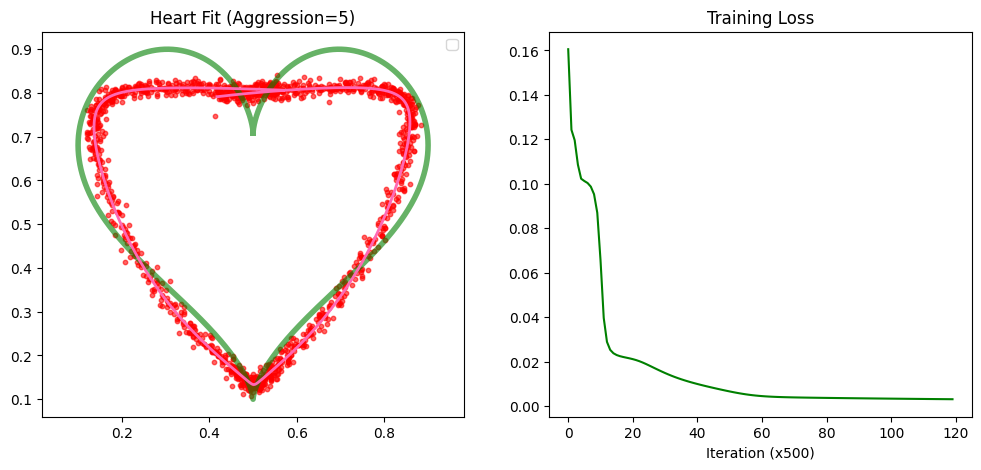

In [1]:
# PACKAGE
import numpy as np
import matplotlib.pyplot as plt


# Here is the activation function and its derivative.
sigma = lambda z : 1 / (1 + np.exp(-z))
d_sigma = lambda z : np.cosh(z/2)**(-2) / 4

# This function initialises the network with it's structure, it also resets any training already done.
def reset_network (n1 = 6, n2 = 7, random=np.random) :
    global W1, W2, W3, b1, b2, b3
    W1 = random.randn(n1, 1) / 2
    W2 = random.randn(n2, n1) / 2
    W3 = random.randn(2, n2) / 2
    b1 = random.randn(n1, 1) / 2
    b2 = random.randn(n2, 1) / 2
    b3 = random.randn(2, 1) / 2

# This function feeds forward each activation to the next layer. It returns all weighted sums and activations.
def network_function(a0) :
    z1 = W1 @ a0 + b1
    a1 = sigma(z1)
    z2 = W2 @ a1 + b2
    a2 = sigma(z2)
    z3 = W3 @ a2 + b3
    a3 = sigma(z3)
    return a0, z1, a1, z2, a2, z3, a3

# This is the cost function of a neural network with respect to a training set.
def cost(x, y) :
    return np.linalg.norm(network_function(x)[-1] - y)**2 / x.size

#Backpropagtion
# GRADED FUNCTION

# Jacobian for the third layer weights. There is no need to edit this function.
def J_W3 (x, y) :
    # First get all the activations and weighted sums at each layer of the network.
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    # We'll use the variable J to store parts of our result as we go along, updating it in each line.
    # Firstly, we calculate dC/da3, using the expressions above.
    J = 2 * (a3 - y)
    # Next multiply the result we've calculated by the derivative of sigma, evaluated at z3.
    J = J * d_sigma(z3)
    # Then we take the dot product (along the axis that holds the training examples) with the final partial derivative,
    # i.e. dz3/dW3 = a2
    # and divide by the number of training examples, for the average over all training examples.
    J = J @ a2.T / x.size
    # Finally return the result out of the function.
    return J

# In this function, you will implement the jacobian for the bias.

def J_b3 (x, y) :
    # As last time, we'll first set up the activations.
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    # Next you should implement the first two partial derivatives of the Jacobian.
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    # We still need to sum over all training examples however.
    J = np.sum(J, axis=1, keepdims=True) / x.size
    return J

# END GRADED FUNCTION
#Layer 1
def J_W2 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    J = W3.T @ J
    J = J * d_sigma(z2)
    J = J @ a1.T / x.size
    return J
def J_b2 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    J = W3.T @ J
    J = J * d_sigma(z2)
    J = np.sum(J, axis=1, keepdims=True) / x.size
    return J
#Layer 0
def J_W1 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    J = W3.T @ J
    J = J * d_sigma(z2)
    J = W2.T @ J
    J = J * d_sigma(z1)
    J = J @ a0.T / x.size
    return J    

def J_b1 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    J = W3.T @ J
    J = J * d_sigma(z2)
    J = W2.T @ J
    J = J * d_sigma(z1)
    J = np.sum(J, axis=1, keepdims=True) / x.size
    return J
# END PACKAGE

#function to Generates coordinates for a heart shape using parametric equations.
def training_data(n=1500):
    """Generates clean coordinates for a heart shape."""
    t = np.linspace(0, 2 * np.pi, n).reshape(1, n)
    
    # Parametric heart equations
    x = 16 * np.sin(t)**3
    y = 13 * np.cos(t) - 5 * np.cos(2*t) - 2 * np.cos(3*t) - np.cos(4*t)
    
    # Normalize to [0.1, 0.9] for sigmoid range
    x_norm = (x - x.min()) / (x.max() - x.min()) * 0.8 + 0.1
    y_norm = (y - y.min()) / (y.max() - y.min()) * 0.8 + 0.1
    
    t_input = t / (2 * np.pi)
    target_output = np.vstack([x_norm, y_norm])
    return t_input, target_output

def plot_training(x, y, iterations=10000, aggression=5, noise=1):
    """
    Trains on clean data x and y.
    'aggression' controls learning rate.
    'noise' controls the jitter of the target visualization only.
    """
    # Map aggression to learning rate
    learning_rate = aggression / 10.0
    
    costs = []
    
    # Training Loop on clean data
    for i in range(iterations):
        global W1, W2, W3, b1, b2, b3
        W1 -= learning_rate * J_W1(x, y)
        b1 -= learning_rate * J_b1(x, y)
        W2 -= learning_rate * J_W2(x, y)
        b2 -= learning_rate * J_b2(x, y)
        W3 -= learning_rate * J_W3(x, y)
        b3 -= learning_rate * J_b3(x, y)
        
        if i % 500 == 0:
            costs.append(cost(x, y))

    # Get smooth prediction from the network
    *_, predictions = network_function(x)
    
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Heart Plot
    plt.subplot(1, 2, 1)
    
    # Target Plot: Smooth Green Line
    plt.plot(y[0, :], y[1, :], color='green', linewidth=4, alpha=0.6)
    # Noisy learned Points: Red Dots
    noisy_predictions = predictions + noise * np.random.randn(*predictions.shape) / 100
    plt.scatter(noisy_predictions[0, :], noisy_predictions[1, :], color='red', s=10, alpha=0.6)  
    # Learned Plot: Smooth Pink Line
    plt.plot(predictions[0, :], predictions[1, :], color='hotpink', linewidth=2)
    plt.title(f"Heart Fit (Aggression={aggression})")
    plt.legend()
    plt.axis("equal")
    
    # Subplot 2: Cost History
    plt.subplot(1, 2, 2)
    plt.plot(costs, color='green')
    plt.title("Training Loss")
    plt.xlabel("Iteration (x500)")
    
    plt.show()

# Run the training
x_train, y_train = training_data()
reset_network()
plot_training(x_train, y_train, iterations=60000, aggression=5, noise=1)
